Importación de librerías

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración visual para gráficos científicos
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

Propiedades de los Fluidos

## 1. Propiedades Físicas

Antes de resolver fluidos, debemos caracterizarlos. Las principales propiedades son:
* **Densidad ($\rho$):** Masa por unidad de volumen ($kg/m^3$).
* **Viscosidad dinámica ($\mu$):** Resistencia interna al flujo ($Pa\cdot s$ o $kg/(m\cdot s)$).
* **Viscosidad cinemática ($\nu$):** Relación entre la viscosidad dinámica y la densidad ($\nu = \mu / \rho$). Mide la difusión del momento en el fluido ($m^2/s$).

Cálculo de propiedades

In [4]:
# Ejemplo: Propiedades del aire y el agua a 20°C a nivel del mar
fluids = {
    'Aire': {'rho': 1.204, 'mu': 1.825e-5},    # rho [kg/m^3], mu [Pa*s]
    'Agua': {'rho': 998.2, 'mu': 1.002e-3}     # rho [kg/m^3], mu [Pa*s]
}

print("--- Viscosidad Cinemática (nu = mu / rho) ---")
for name, props in fluids.items():
    nu = props['mu'] / props['rho']
    print(f"{name}: {nu:.2e} m^2/s")

--- Viscosidad Cinemática (nu = mu / rho) ---
Aire: 1.52e-05 m^2/s
Agua: 1.00e-06 m^2/s


## 2. Número de Reynolds ($Re$)

El Número de Reynolds predice si el flujo será **laminar** (suave, predecible) o **turbulento** (caótico, con remolinos). Es la relación entre fuerzas inerciales y fuerzas viscosas.

$$Re = \frac{\rho V L}{\mu} = \frac{V L}{\nu}$$

Donde:
* $V$: Velocidad característica ($m/s$)
* $L$: Longitud característica (cuerda del perfil, diámetro del tubo, etc.) ($m$)

**Criterios generales (Flujo interno):**
* $Re < 2300 \rightarrow$ Flujo Laminar
* $2300 \le Re \le 4000 \rightarrow$ Transición
* $Re > 4000 \rightarrow$ Flujo Turbulento

Calculadora y visualización del Número de Reynolds

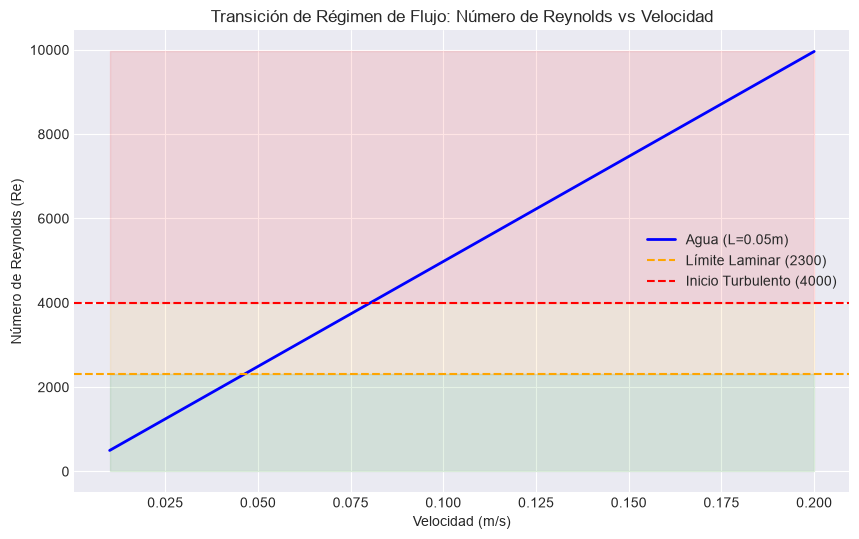

A 0.1 m/s, Re = 4981 (Turbulento)


In [5]:
def classify_flow(reynolds):
    if reynolds < 2300:
        return "Laminar"
    elif reynolds < 4000:
        return "Transición"
    else:
        return "Turbulento"

# Análisis de sensibilidad: ¿Cómo cambia el régimen de flujo del agua 
# en una tubería de 0.05m (5cm) al aumentar la velocidad?
L_tubo = 0.05 # m
velocidades = np.linspace(0.01, 0.2, 100) # De 1cm/s a 20cm/s
agua_nu = fluids['Agua']['mu'] / fluids['Agua']['rho']

reynolds_array = (velocidades * L_tubo) / agua_nu

# Visualización
plt.plot(velocidades, reynolds_array, label='Agua (L=0.05m)', color='blue', linewidth=2)
plt.axhline(y=2300, color='orange', linestyle='--', label='Límite Laminar (2300)')
plt.axhline(y=4000, color='red', linestyle='--', label='Inicio Turbulento (4000)')

plt.title('Transición de Régimen de Flujo: Número de Reynolds vs Velocidad')
plt.xlabel('Velocidad (m/s)')
plt.ylabel('Número de Reynolds (Re)')
plt.fill_between(velocidades, 0, 2300, alpha=0.1, color='green')
plt.fill_between(velocidades, 2300, 4000, alpha=0.1, color='orange')
plt.fill_between(velocidades, 4000, np.max(reynolds_array), alpha=0.1, color='red')
plt.legend()
plt.show()

print(f"A 0.1 m/s, Re = {((0.1 * L_tubo) / agua_nu):.0f} ({classify_flow((0.1 * L_tubo) / agua_nu)})")

## 3. Las Ecuaciones de Navier-Stokes (Flujo de Poiseuille)

La ecuación de conservación de momento de Navier-Stokes para un fluido incompresible es:

$$\rho \left( \frac{\partial \vec{u}}{\partial t} + \vec{u}\cdot\nabla\vec{u} \right) = -\nabla p+ \mu\nabla^2\vec{u}$$

Para comprender su estructura antes de discretizarla en la Fase 4, graficaremos su **solución analítica exacta** para un caso 1D simplificado: el Flujo de Poiseuille (flujo laminar entre dos placas paralelas fijas impulsado por un gradiente de presión).

La distribución de velocidad $u(y)$ forma una parábola:
$$u(y) = \frac{1}{2\mu} \frac{dp}{dx} (y^2 - h y)$$

Donde $h$ es la distancia entre las placas y $\frac{dp}{dx}$ es el gradiente de presión.

Visualización del perfil de velocidad (Poiseuille)

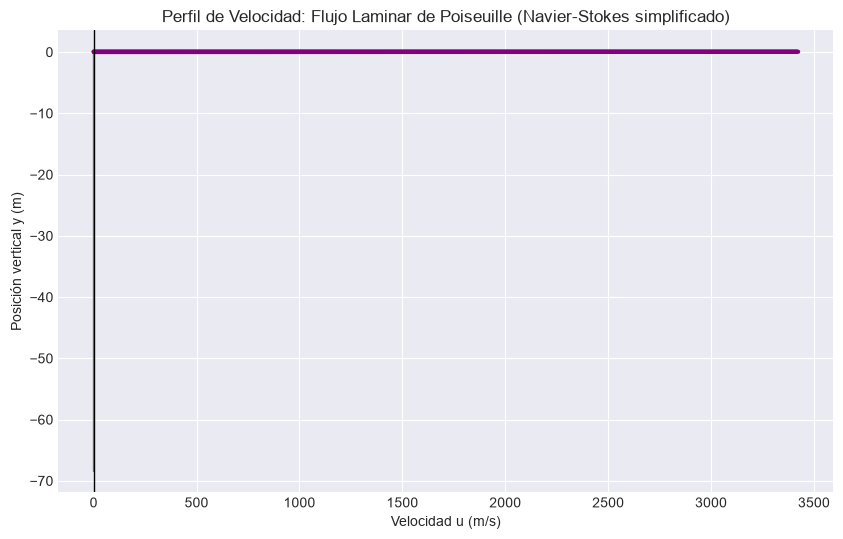

In [6]:
# Parámetros del flujo entre placas
h = 0.1 # Distancia entre placas (m)
dp_dx = -50.0 # Gradiente de presión adverso (Pa/m) - negativo porque la presión baja en dir del flujo
mu = fluids['Aire']['mu'] # Usando aire

# Discretización espacial del eje Y (50 puntos entre 0 y h)
y = np.linspace(0, h, 50)

# Solución analítica de la ecuación diferencial
u = (1 / (2 * mu)) * dp_dx * (y**2 - h*y)

# Gráfico del perfil de velocidad
plt.plot(u, y, color='purple', linewidth=3)
plt.axvline(x=0, color='black', linewidth=1) # Eje Y (velocidad cero en las paredes - no slip)
plt.title('Perfil de Velocidad: Flujo Laminar de Poiseuille (Navier-Stokes simplificado)')
plt.xlabel('Velocidad u (m/s)')
plt.ylabel('Posición vertical y (m)')

# Dibujar vectores de velocidad
for i in range(0, len(y), 3):
    plt.arrow(0, y[i], u[i], 0, head_width=0.002, head_length=np.max(u)*0.02, 
              fc='gray', ec='gray', length_includes_head=True)

plt.show()